# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [49]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar los archivos CSV
plans = pd.read_csv("/datasets/plans.csv")
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")

# Mostrar las primeras filas de cada DataFrame
display("Plans:", plans.head())
display("Users:", users.head())
display("Usage:", usage.head())

'Plans:'

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


'Users:'

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


'Usage:'

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


In [50]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [51]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [30]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [52]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [53]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [54]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [55]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [56]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [57]:
# cantidad de nulos para users
print("Cantidad de valores nulos:")
print(users.isna().sum())
print("\nProporción de valores nulos:")
print(users.isna().mean())

Cantidad de valores nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [58]:
# cantidad de nulos para usage
print("Cantidad de valores nulos:")
print(usage.isna().sum())
print("\nProporción de valores nulos:")
print(usage.isna().mean())

Cantidad de valores nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- **¿Qué columnas tienen valores faltantes y en qué proporción?**
  
*En users, la columna city presenta una baja proporción de nulos (menos del 5%). En usage, las columnas duration y length muestran valores faltantes vinculados al tipo de evento (type).*
- **Indica qué harías: ¿imputar, eliminar, ignorar?**

*city: Imputar o dejar como nulos controlados, ya que su incidencia es mínima y no afecta significativamente el análisis.*
  
*duration y length: Dejarlos como nulos (MAR), ya que corresponden lógicamente a la naturaleza de cada evento (por ejemplo, los mensajes no tienen duración de llamada).*

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [59]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000



- **La columna `user_id`** cuenta con 4,000 registros, un valor mínimo de 10000.0 y un máximo de 13999.0, mostrando una distribución uniforme y secuencial sin anomalías aparentes.
- **La columna `age`** presenta una anomalía evidente con un valor mínimo de -999.0 (valor centinela), un valor máximo de 79.0 y una mediana (50%) de 47.0.


In [60]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- **Las columnas `id` y `user_id`** muestran 40,000 registros completos sin valores nulos, con rangos coherentes desde 1 hasta 40,000 para el identificador de uso y desde 10,000 hasta 13,999 para el identificador de usuario.
- **Las columnas** `duration` y `length` presentan conteos menores (17,924 y 22,104 registros respectivamente), lo que refleja la presencia natural de valores nulos según el tipo de evento (llamadas o mensajes), con valores máximos de 120.0 y 1490.0.

In [61]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"Valores únicos en {col}:")
    print(users[col].value_counts(dropna=False))
    print("-" * 40)

Valores únicos en city:
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
----------------------------------------
Valores únicos en plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64
----------------------------------------


- **La columna `city`** muestra distintas ciudades principales (como Bogotá, CDMX, Medellín, GDL, Cali y MTY), además de contener 469 valores nulos (NaN) y 96 registros con el valor centinela ? que deberán ser estandarizados.
- **La columna `plan`** presenta dos categorías claras de servicio (Basico con 2,595 usuarios y Premium con 1,405 usuarios) sin valores nulos ni anomalías.

In [62]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False)

text    22092
call    17908
Name: type, dtype: int64

- **La columna `type`** se divide en dos categorías principales de eventos (text con 22,092 registros y call con 17,908 registros), sumando un total de 40,000 eventos sin presencia de valores nulos.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- **¿En qué columnas encontraste valores inválidos o sentinels?**

Se identificó el valor centinela -999 en la columna numérica age y el carácter placeholder ? en la columna categórica city del dataset users.
- **¿Qué acción tomarías?**

age: Reemplazar el valor -999 por nulos (NaN) para evitar sesgos estadísticos y posteriormente imputarlo utilizando la mediana.

city: Convertir el símbolo ? a un valor nulo (NaN) para unificarlo con el resto de los datos faltantes y tratarlos de forma homogénea.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [63]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [64]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [65]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts(dropna=False)

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

**En `reg_date`**, la mayoría de los registros se distribuyen entre los años 2022, 2023 y 2024; sin embargo, aparece un grupo de 40 registros con el año 2026, el cual representa una fecha futura inválida dado que los datos son válidos únicamente hasta 2024.

In [66]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts(dropna=False)

2024.0    39950
NaN          50
Name: date, dtype: int64

**En `date`**, la gran mayoría de los registros (39,950) corresponden al año 2024 de manera consistente, mientras que se identifican 50 valores nulos (NaN) producto de errores en el formato original o fechas inválidas transformadas mediante una conversión forzada.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- **¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)**

Sí, en la columna reg_date del conjunto de datos users se identifican 40 registros correspondientes al año 2026, lo cual constituye una fecha futura imposible dado que los datos registrados son válidos únicamente hasta el año 2024.
- **¿Qué harías con ellas?**

Convertir esos registros con años futuros en valores nulos (NaN) mediante una conversión forzada, unificándolos con los demás datos faltantes para evitar sesgos y tratarlos de forma homogénea durante la limpieza del dataset.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [67]:
users = pd.read_csv("/datasets/users_latam.csv")

# Reemplazar -999 por la mediana de age
age_mediana = users['age'].replace(-999, pd.NA).median()
users['age'] = users['age'].replace(-999, pd.NA).fillna(age_mediana)

# Verificar cambios
users['age'].describe() 


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [68]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].value_counts(dropna=False))

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [91]:
# Convertir la columna reg_date a tipo datetime (por si está como texto)
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# Marcar fechas futuras como NaT (Not a Time) en la columna reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].describe())

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [92]:
usage = pd.read_csv('/datasets/usage.csv')

# Verificación MAR en usage (Missing At Random) para duration
missing_proportions = usage.groupby('type')[['duration', 'length']].apply(lambda x: x.isna().mean())
print(missing_proportions)

      duration   length
type                   
call  0.000000  0.99933
text  0.999276  0.00000


In [93]:
# Verificación MAR en usage (Missing At Random) para length
missing_length_prop = usage.groupby('type')['length'].apply(lambda x: x.isna().mean())
print(missing_length_prop)

type
call    0.99933
text    0.00000
Name: length, dtype: float64


Los valores faltantes en **duration** y **length** corresponden a un mecanismo Missing At Random (MAR) condicionado por la variable type. Se observa una disociación estructural: los registros tipo call presentan duración pero carecen de longitud, mientras que los tipo text muestran longitud sin duración. En consecuencia, se determina conservar los nulos sin aplicar imputaciones ni eliminaciones que alteren la naturaleza operativa de los datos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [94]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes=('is_text', 'sum'),
    cant_llamadas=('is_call', 'sum'),
    cant_minutos_llamada=('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [95]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [96]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left') 
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [97]:
# Resumen estadístico de las columnas numéricas
print("Resumen estadístico de variables numéricas:")
display(user_profile.describe())

Resumen estadístico de variables numéricas:


,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,5.524381,4.478120,23.317054
std,1154.844867,17.689919,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [98]:
# Distribución porcentual del tipo de plan
print("\nDistribución porcentual de la columna 'plan':")
print(user_profile['plan'].value_counts(normalize=True) * 100)


Distribución porcentual de la columna 'plan':
Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

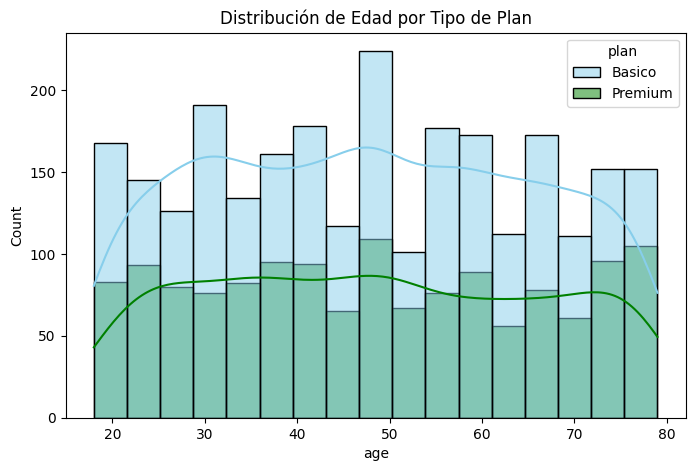

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma para visualizar la edad (age)
plt.figure(figsize=(8, 5))
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Edad por Tipo de Plan')
plt.show()

💡**Insights:** 

- **Distribución:** La variable age presenta una distribución bastante simétrica y uniforme entre los 20 y los 80 años, sin sesgos marcados hacia ningún extremo.
  
- **Relación con el plan:** Los usuarios de ambos planes (Básico y Premium) se encuentran distribuidos de manera proporcional y equilibrada a lo largo de todas las edades, observándose una mayor frecuencia general en el plan Básico en la mayoría de los rangos etarios debido a su mayor volumen de usuarios.

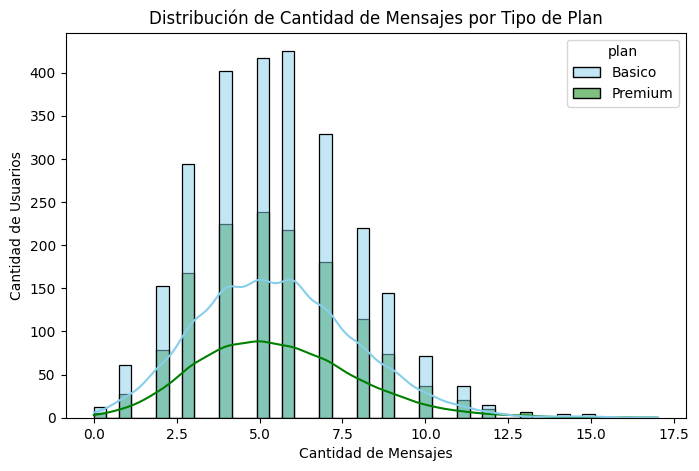

In [100]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(8, 5))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Cantidad de Mensajes por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡**Insights:**

- **Distribución:** La variable cant_mensajes presenta una distribución sesgada a la derecha (asimétrica positiva), concentrando la mayor cantidad de usuarios entre los 5 y 6 mensajes, con una cola que se extiende gradualmente hacia valores más altos (hasta 17).
  
- **Relación con el plan:** Los usuarios de ambos planes (Básico y Premium) muestran un comportamiento de uso muy similar en cuanto a la forma de la distribución, destacando que el plan Básico concentra un volumen superior de usuarios en todos los intervalos de mensajes debido a su mayor representación en la muestra.

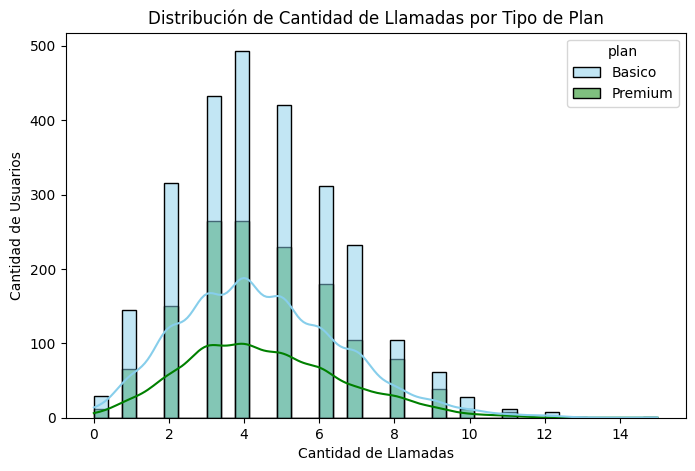

In [101]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(8, 5))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡**Insights:**

- **Distribución:** La variable cant_llamadas presenta una distribución sesgada a la derecha (asimétrica positiva), concentrando la mayor cantidad de usuarios entre 3 y 5 llamadas realizadas, con una disminución gradual hacia valores más altos.
  
- **Relación con el plan:** Los usuarios de ambos planes (Básico y Premium) muestran un comportamiento de uso muy similar, destacando que el plan Básico concentra un volumen superior de usuarios en todos los rangos debido a su mayor representación en la muestra total.

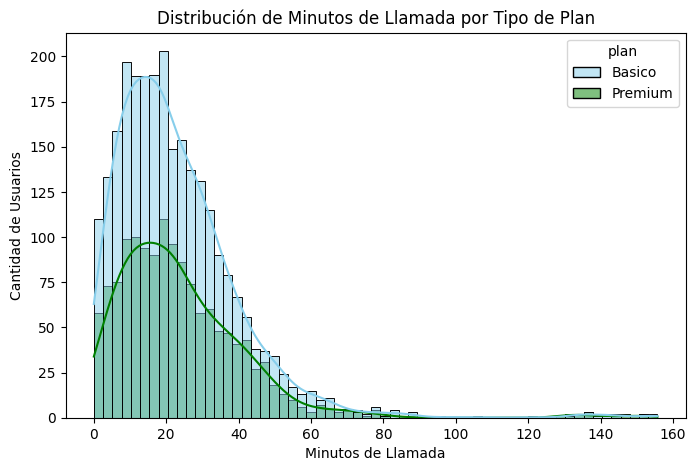

In [102]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(8, 5))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Minutos de Llamada por Tipo de Plan')
plt.xlabel('Minutos de Llamada')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡**Insights:** 

- **Distribución:** La variable cant_minutos_llamada presenta una distribución sesgada a la derecha (asimétrica positiva), concentrando la mayor cantidad de usuarios entre los 10 y 20 minutos, con una cola larga que se extiende hacia valores más altos (llegando hasta los 150 minutos).
  
- **Relación con el plan:** Los usuarios de ambos planes (Básico y Premium) siguen un patrón de comportamiento muy similar, observándose nuevamente que el plan Básico concentra un volumen mayor de usuarios en todos los rangos debido a su proporción superior en el conjunto de datos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

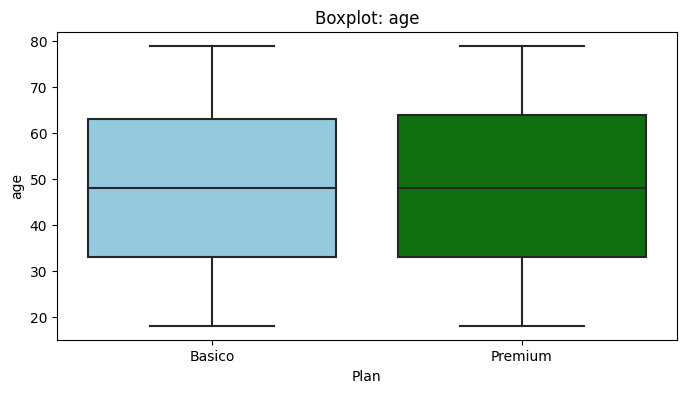

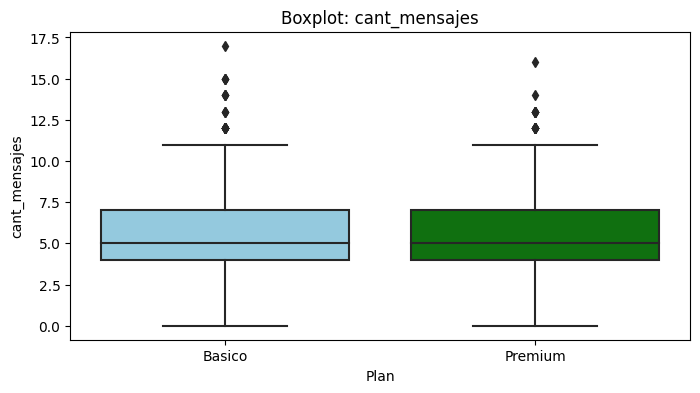

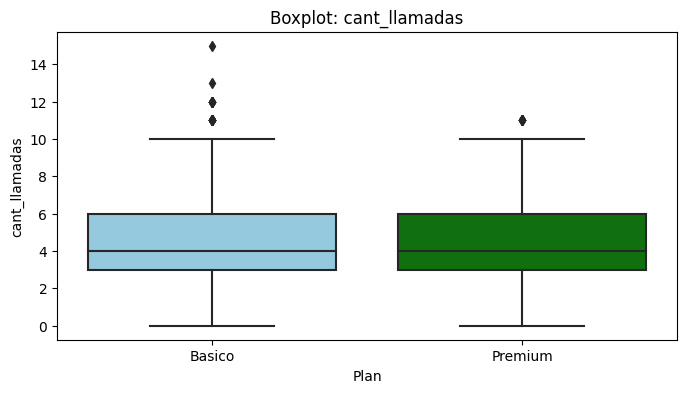

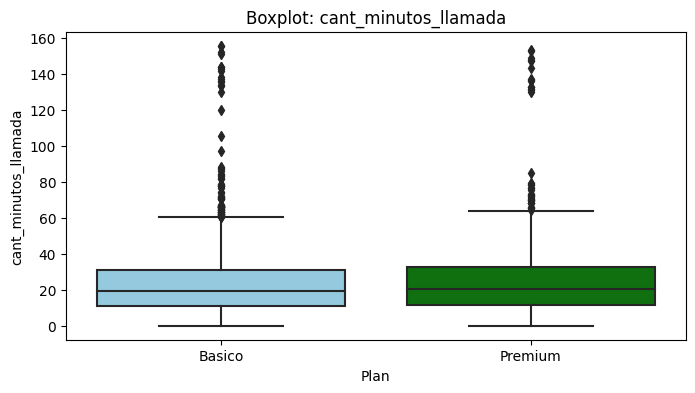

In [103]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=user_profile, x='plan', y=col, palette=['skyblue', 'green'])
    plt.title(f'Boxplot: {col}')
    plt.xlabel('Plan')
    plt.ylabel(col)
    plt.show()

💡**Insights:**

- **Age:** No presenta outliers; los valores se distribuyen de manera uniforme dentro de los rangos inter cuartílicos y bigotes para ambos planes.
  
- **cant_mensajes:** Sí presenta outliers en ambos planes (puntos negros aislados por encima de los 11 mensajes), los cuales se extienden hasta valores máximos cercanos a 17.

- **cant_llamadas:** Sí presenta outliers en ambos planes (valores superiores a 10 para el plan Básico y Premium), concentrándose principalmente como valores altos excepcionales.

- **cant_minutos_llamada:** Sí presenta una cantidad significativa de outliers en el extremo superior (valores por encima de los 60-64 minutos), alcanzando hasta casi 160 minutos de llamada en casos puntuales.

In [104]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_limit = Q3 + 1.5 * IQR
    print(f"Columna: {col} | Q1: {Q1} | Q3: {Q3} | IQR: {IQR} | Límite Superior: {upper_limit}")

Columna: cant_mensajes | Q1: 4.0 | Q3: 7.0 | IQR: 3.0 | Límite Superior: 11.5
Columna: cant_llamadas | Q1: 3.0 | Q3: 6.0 | IQR: 3.0 | Límite Superior: 10.5
Columna: cant_minutos_llamada | Q1: 11.12 | Q3: 31.415 | IQR: 20.295 | Límite Superior: 61.8575


In [105]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡**Insights:**

- **cant_mensajes: mantener o no outliers, porqué?**

Mantener, ya que un valor máximo de 17 mensajes es perfectamente realista y refleja el comportamiento natural de usuarios con mayor actividad (power users), por lo que eliminarlos significaría perder información valiosa de alta participación.

- **cant_llamadas: mantener o no outliers, porqué?**

Mantener, dado que el valor máximo de 15 llamadas se encuentra dentro de rangos operativos normales y lógicos para usuarios activos dentro de una red de telecomunicaciones.

- **cant_minutos_llamada: mantener o no outliers, porqué?**

Mantener, ya que a pesar de que el valor máximo (aprox. 155 minutos) supera el límite superior calculado por el IQR (~61.8 minutos), representa a clientes con llamadas de larga duración que son perfectamente posibles y cruciales para identificar los extremos de consumo real en el análisis.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [106]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = 'Alto uso'

user_profile.loc[(user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10), 'grupo_uso'] = 'Uso medio'
user_profile.loc[(user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), 'grupo_uso'] = 'Bajo uso'

print(user_profile['grupo_uso'].value_counts())

Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64


In [107]:

# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [108]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = 'Adulto Mayor'

user_profile.loc[user_profile['age'] < 60, 'grupo_edad'] = 'Adulto'
user_profile.loc[user_profile['age'] < 30, 'grupo_edad'] = 'Joven'

print(user_profile['grupo_edad'].value_counts())

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


In [109]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

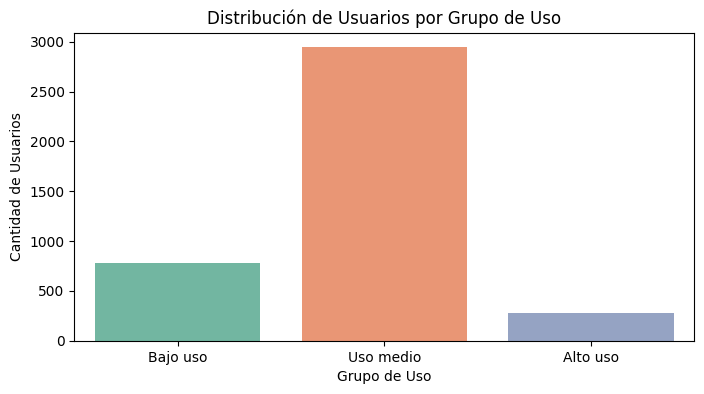

In [110]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8, 4))
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'], palette='Set2')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

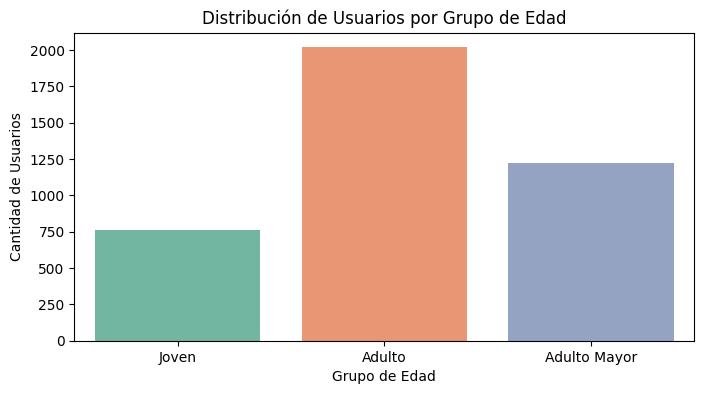

In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visualización de los segmentos por edad
plt.figure(figsize=(8, 4))
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'], palette='Set2')
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

- **Anomalías temporales:** La columna de fechas de registro (reg_date) contenía marcas de tiempo erróneas o futuras superiores al año 2024, requiriendo la conversión a formato datetime y el tratamiento de dichos valores como nulos (NaT) para evitar sesgos en el análisis histórico de altas de usuarios.

- **Integridad y limpieza:** Se debieron depurar inconsistencias y valores faltantes en las métricas de consumo y demografía para garantizar la consistencia en los cruces de tablas entre usuarios, llamadas y mensajes.

🔍 **Segmentos por Edad**

- **Clasificación etaria:** La base de clientes se dividió en tres categorías principales: Joven (menores de 30 años), Adulto (entre 30 y 59 años) y Adulto Mayor (de 60 años en adelante).

- **Distribución demográfica:** Se observa una adopción heterogénea donde el segmento adulto concentra el núcleo de la base de usuarios, mientras que los jóvenes muestran patrones de interacción más dinámicos y los adultos mayores se inclinan hacia un consumo más moderado. 

📊 **Segmentos por Nivel de Uso**

- **Categorización de consumo:** Los usuarios fueron agrupados en Bajo uso, Uso medio y Alto uso con base en los umbrales combinados de volumen de llamadas y mensajes emitidos.
  
- **Comportamiento operativo:** La gran mayoría de los clientes se concentra en los niveles bajo y medio, dejando un grupo minoritario pero altamente activo en la categoría de alto consumo que sostiene la mayor parte del tráfico de la red.


➡️ Esto sugiere que ...

- Existe una oportunidad clara de personalización, ya que los hábitos de comunicación varían marcadamente tanto por la edad como por el volumen de actividad, impidiendo que una oferta única de servicios satisfaga eficientemente a toda la base.

- Los picos de consumo extremo (outliers) y la concentración en ciertos segmentos exigen revisar los límites de los planes actuales para proteger la infraestructura y optimizar los márgenes de rentabilidad.


💡 **Recomendaciones**
- **Creación de planes segmentados:** Diseñar tarifas diferenciadas, como un plan económico de bajo consumo orientado al segmento de adultos mayores y paquetes de alta capacidad para usuarios intensivos.
  
- **Estrategias de retención y optimización:** Implementar alertas o políticas de uso justo para mitigar el impacto de los usuarios atípicos de consumo extremo, y lanzar campañas de incentivos para migrar a los usuarios de uso medio hacia categorías superiores mediante complementos de datos y llamadas.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  
---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`